# Cambodia Rental EDA (Khmer24)

This notebook performs a complete 5-phase exploratory data analysis on the cleaned Khmer24 rental dataset and saves all charts to `outputs/charts/`.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)

# Robust project-root detection from notebook cwd.
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "data_cleaning").exists():
    project_root = project_root.parent

if not (project_root / "data_cleaning").exists():
    raise FileNotFoundError("Could not find project root containing data_cleaning/.")

input_path = project_root / "data_cleaning" / "Khmer24_cleaned_v4.csv"
chart_dir = project_root / "outputs" / "charts"
chart_dir.mkdir(parents=True, exist_ok=True)

print(f"Input: {input_path}")
print(f"Chart output: {chart_dir}")

Input: /home/megheng/CADT/data science/Property-Price-Prediction/data_cleaning/Khmer24_cleaned_v4.csv
Chart output: /home/megheng/CADT/data science/Property-Price-Prediction/outputs/charts


In [4]:
# Load and prepare data
required_cols = [
    "listing_id", "city", "district", "location", "property_type",
    "rent_price_usd", "size_sqm", "bedrooms", "bathrooms"
]

df = pd.read_csv(input_path)
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

for c in ["rent_price_usd", "size_sqm", "bedrooms", "bathrooms"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["rent_price_usd", "size_sqm", "bedrooms", "bathrooms", "property_type"])
df = df[df["size_sqm"] > 0].copy()

df["log_rent"] = np.log1p(df["rent_price_usd"])
df["price_per_sqm"] = df["rent_price_usd"] / df["size_sqm"]
df["room_ratio"] = np.where(df["bedrooms"] > 0, df["bathrooms"] / df["bedrooms"], np.nan)
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["price_per_sqm", "room_ratio"])

print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Rows: 983
Columns: ['listing_id', 'city', 'district', 'location', 'property_type', 'rent_price_usd', 'size_sqm', 'bedrooms', 'bathrooms', 'log_rent', 'price_per_sqm', 'room_ratio', 'total_rooms']


## Phase 1 — Univariate Analysis

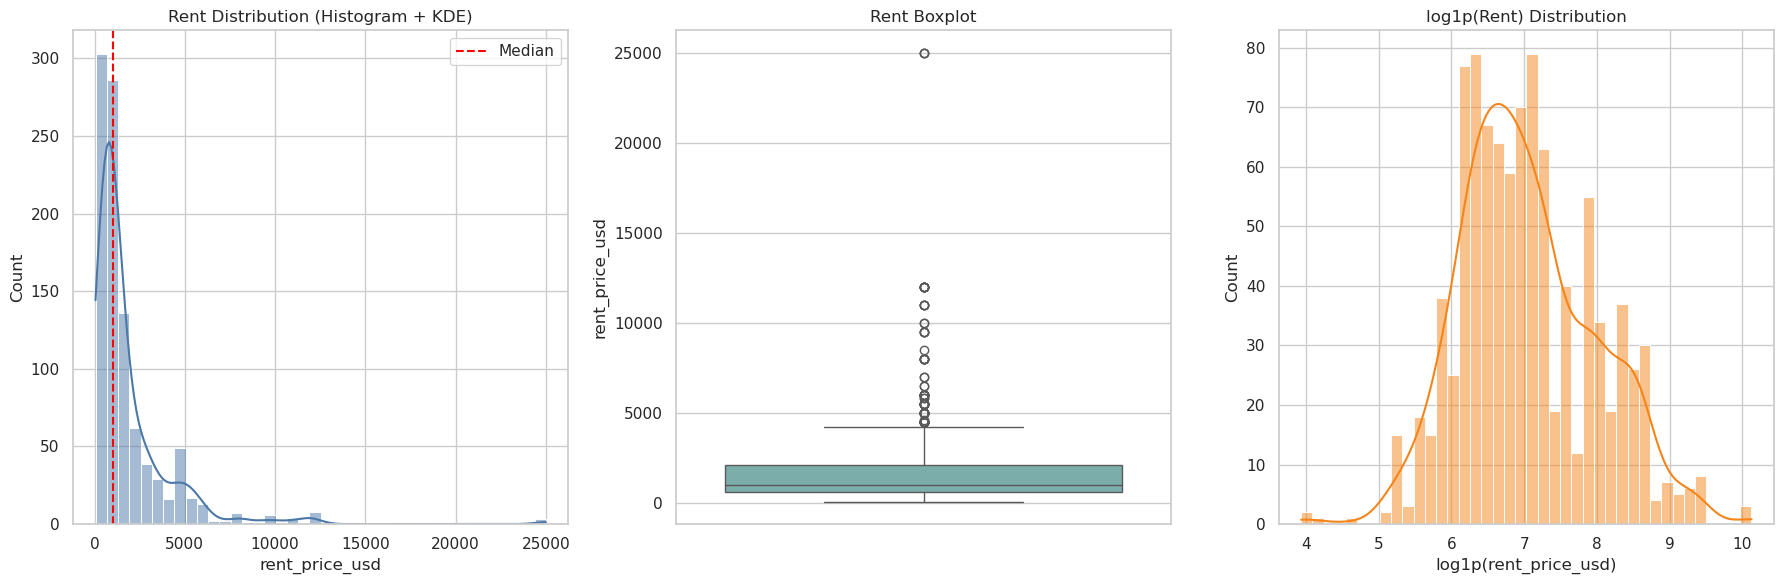

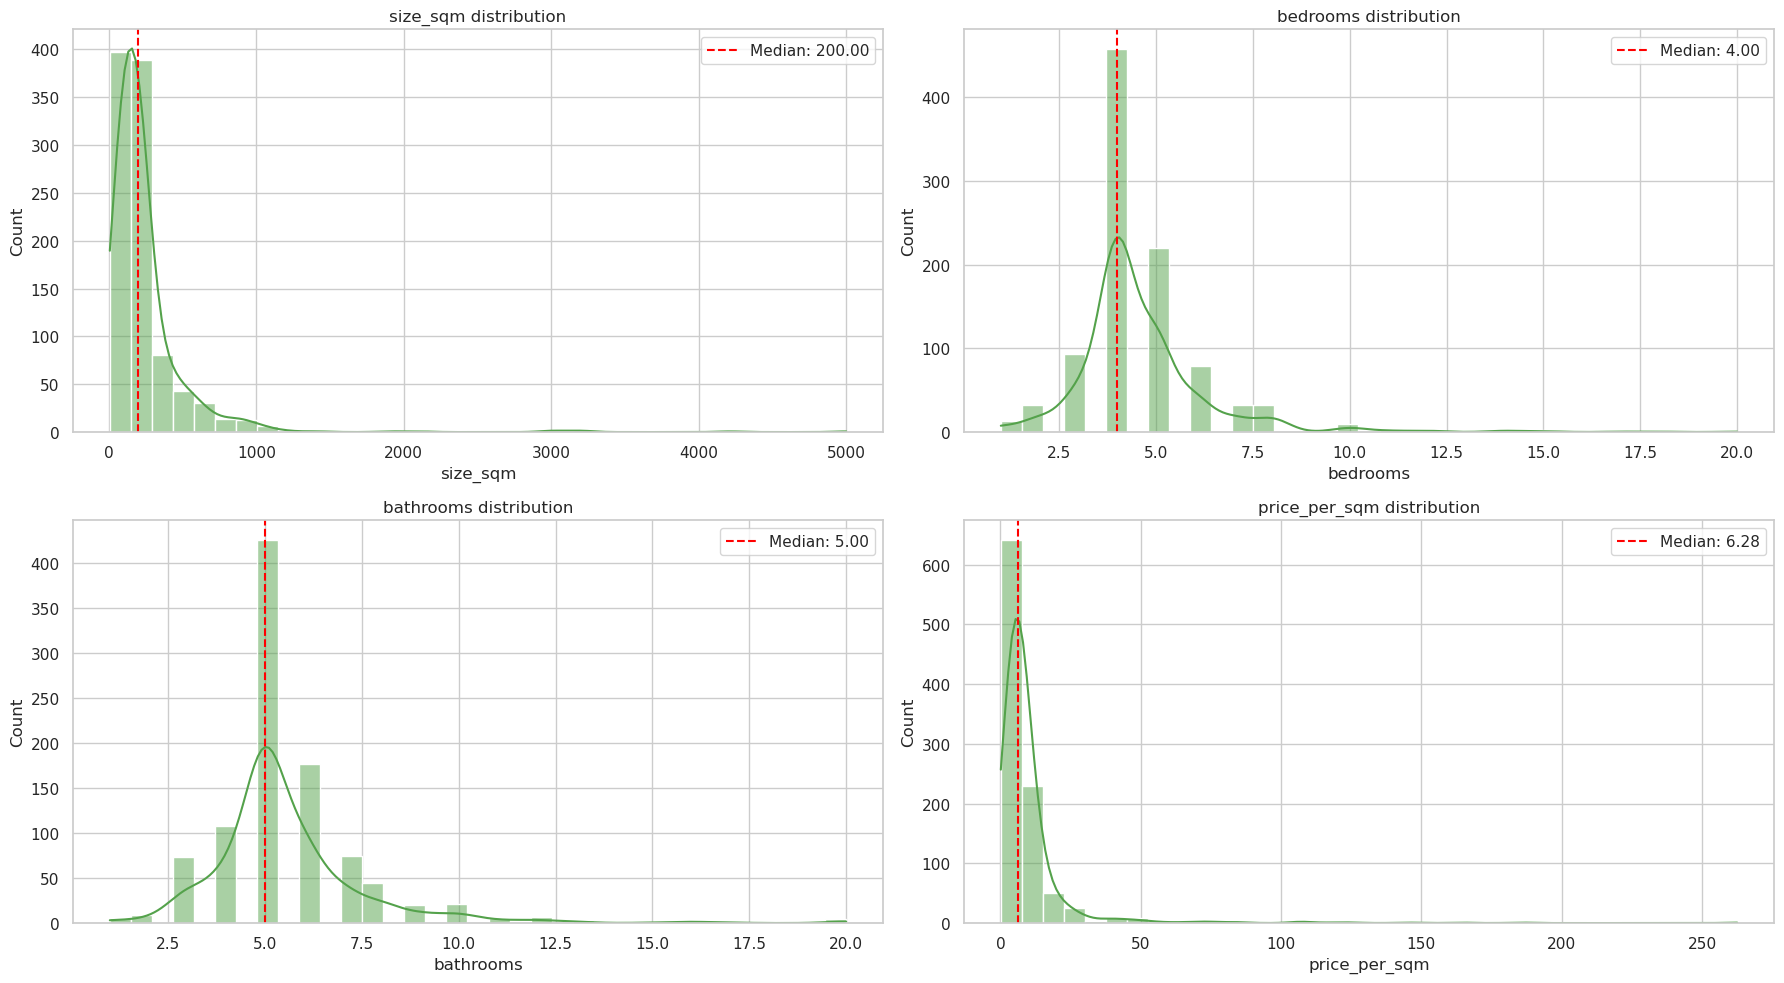

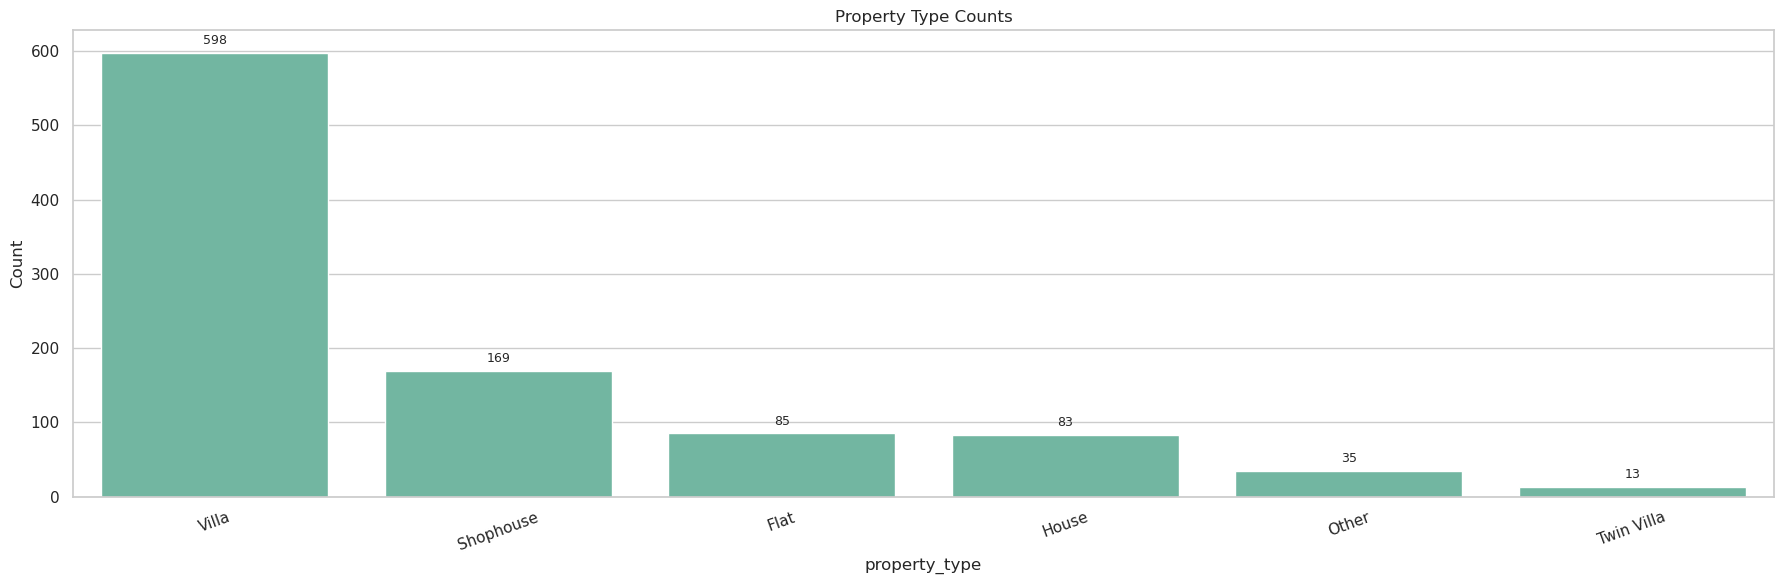

Phase 1 stats
  mean: 1830.92
  median: 1000.00
  std: 2360.03
  min: 50.00
  max: 25000.00
  skewness: 4.38
  kurtosis: 30.95

Property type distribution
               count  percent
property_type                
Villa            598    60.83
Shophouse        169    17.19
Flat              85     8.65
House             83     8.44
Other             35     3.56
Twin Villa        13     1.32

Log transformation needed? YES

Insight: Rent is heavily right-skewed, with most listings at lower price bands and a long luxury tail.
Log transformation improves distribution shape and should be used before training.
Business interpretation: Price benchmarks should be segmented by property type to avoid distortion from villa-heavy data.


In [7]:
rent_stats = {
    "mean": df["rent_price_usd"].mean(),
    "median": df["rent_price_usd"].median(),
    "std": df["rent_price_usd"].std(),
    "min": df["rent_price_usd"].min(),
    "max": df["rent_price_usd"].max(),
    "skewness": df["rent_price_usd"].skew(),
    "kurtosis": df["rent_price_usd"].kurtosis(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(df["rent_price_usd"], bins=40, kde=True, ax=axes[0], color="#4C78A8")
axes[0].axvline(rent_stats["median"], color="red", linestyle="--", linewidth=1.5, label="Median")
axes[0].set_title("Rent Distribution (Histogram + KDE)")
axes[0].set_xlabel("rent_price_usd")
axes[0].set_ylabel("Count")
axes[0].legend()

sns.boxplot(y=df["rent_price_usd"], ax=axes[1], color="#72B7B2")
axes[1].set_title("Rent Boxplot")
axes[1].set_ylabel("rent_price_usd")

sns.histplot(df["log_rent"], bins=40, kde=True, ax=axes[2], color="#F58518")
axes[2].set_title("log1p(Rent) Distribution")
axes[2].set_xlabel("log1p(rent_price_usd)")
axes[2].set_ylabel("Count")

fig.tight_layout()
fig.savefig(chart_dir / "phase1_rent_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, col in zip(axes.ravel(), ["size_sqm", "bedrooms", "bathrooms", "price_per_sqm"]):
    sns.histplot(df[col], bins=35, kde=True, ax=ax, color="#54A24B")
    med = df[col].median()
    ax.axvline(med, color="red", linestyle="--", linewidth=1.5, label=f"Median: {med:.2f}")
    ax.set_title(f"{col} distribution")
    ax.legend()

fig.tight_layout()
fig.savefig(chart_dir / "phase1_numeric_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(18, 6))
type_counts = df["property_type"].value_counts().sort_values(ascending=False)
bars = sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax, color=sns.color_palette("Set2")[0])
for p in bars.patches:
    ax.annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9, xytext=(0, 4), textcoords="offset points")
ax.set_title("Property Type Counts")
ax.set_xlabel("property_type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(chart_dir / "phase1_categorical.png", dpi=200, bbox_inches="tight")
plt.show()

print("Phase 1 stats")
for k, v in rent_stats.items():
    print(f"  {k}: {v:.2f}")
print("\nProperty type distribution")
print((type_counts.to_frame("count").assign(percent=(type_counts / len(df) * 100).round(2))).to_string())
print(f"\nLog transformation needed? {'YES' if rent_stats['skewness'] > 1 else 'NO'}")

print("\nInsight: Rent is heavily right-skewed, with most listings at lower price bands and a long luxury tail.")
print("Log transformation improves distribution shape and should be used before training.")
print("Business interpretation: Price benchmarks should be segmented by property type to avoid distortion from villa-heavy data.")

## Phase 2 — Bivariate Analysis

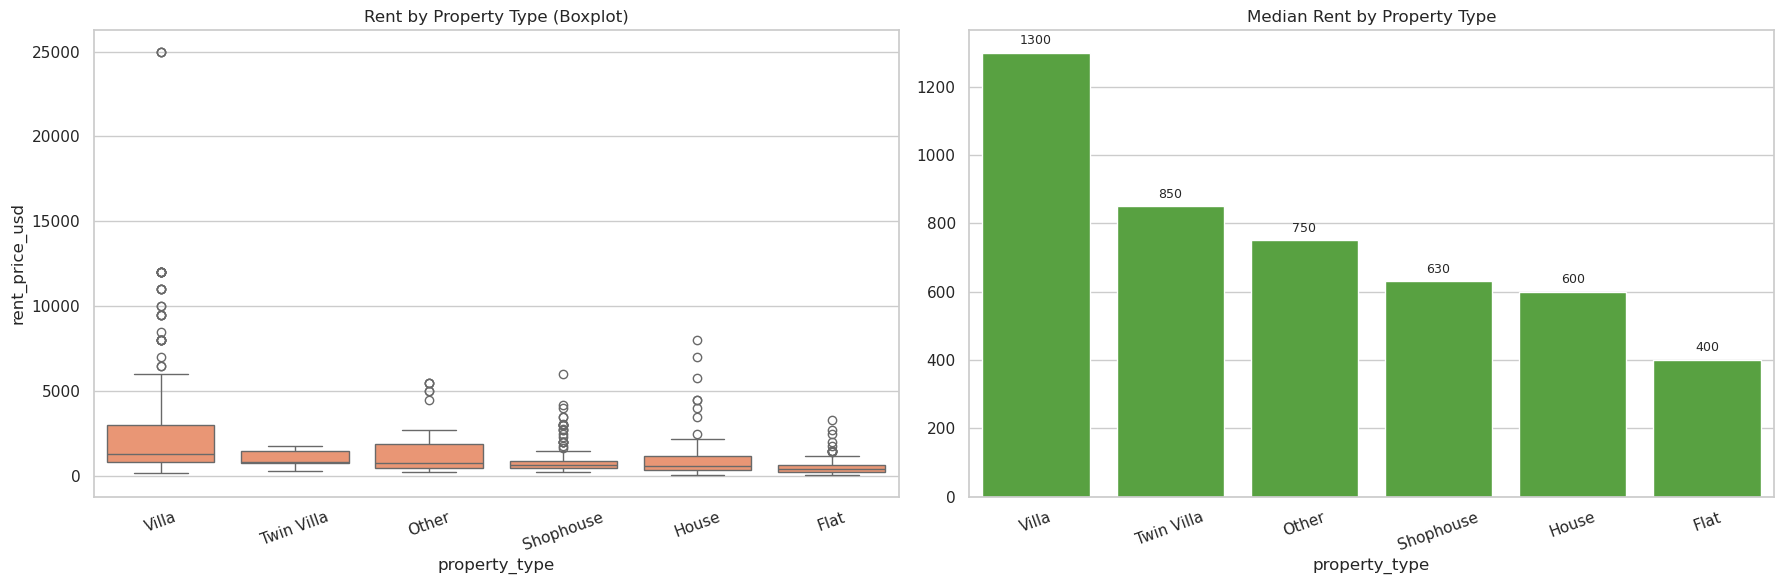

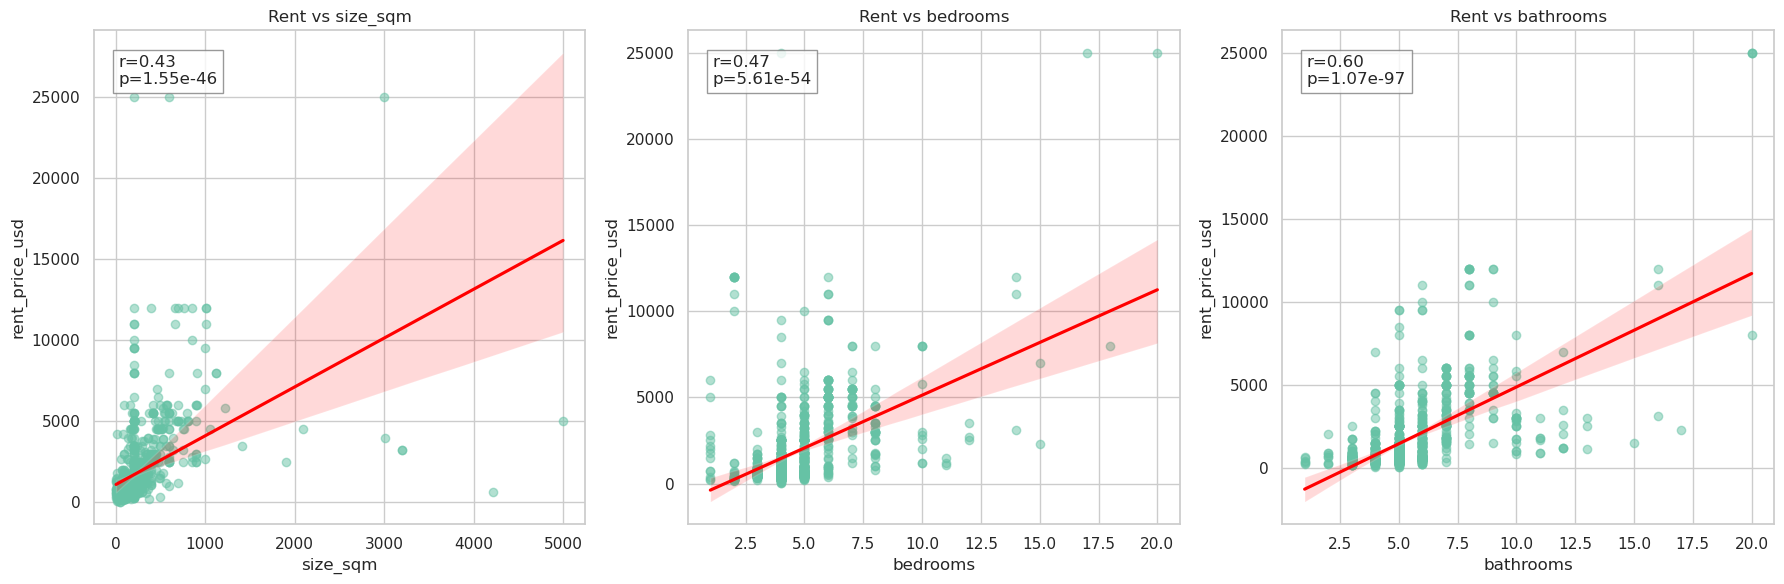

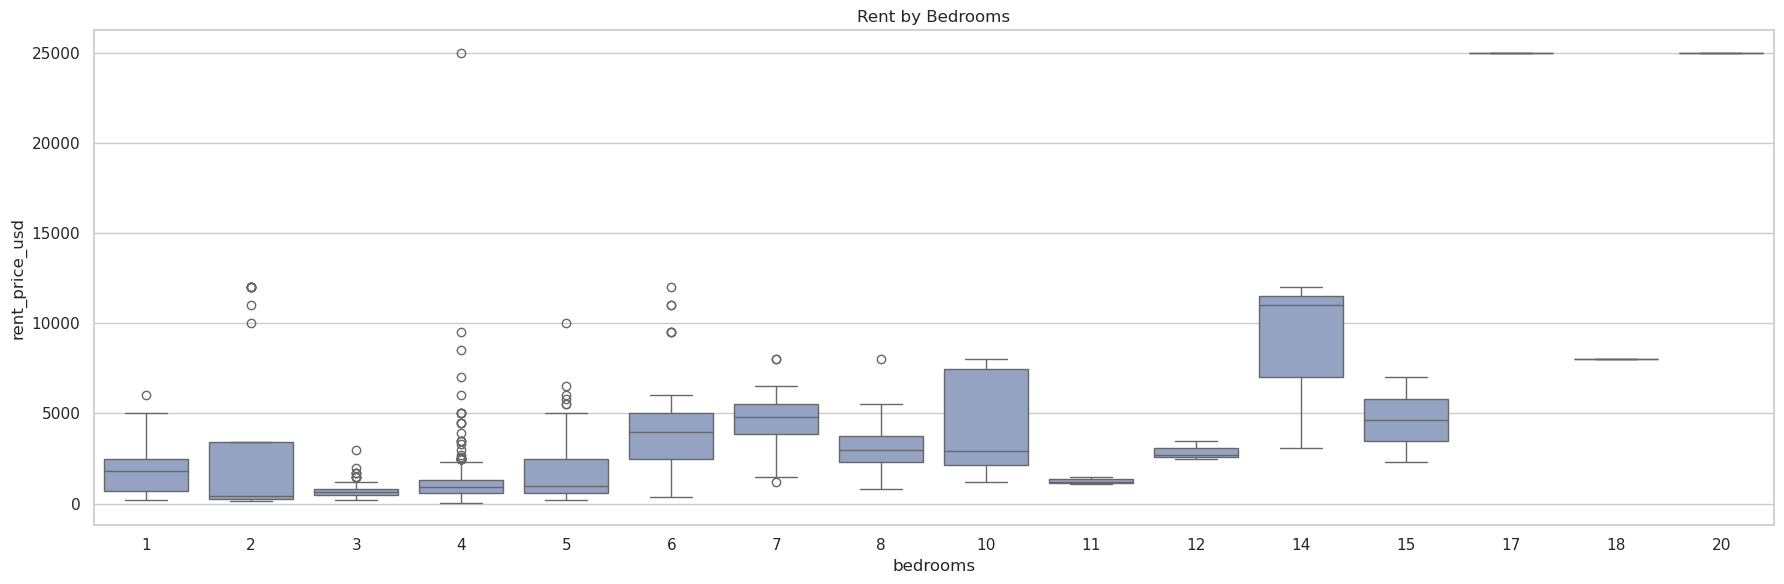

Phase 2 stats

Median rent per property_type
property_type
Villa         1300.0
Twin Villa     850.0
Other          750.0
Shophouse      630.0
House          600.0
Flat           400.0

Pearson r and p-value
  size_sqm: r=0.43, p=1.55e-46
  bedrooms: r=0.47, p=5.61e-54
  bathrooms: r=0.60, p=1.07e-97

Insight: Villas and high-room-count homes command higher rents with wider variance.
Bathrooms shows the strongest linear relationship with rent among numeric features.
Business interpretation: Structural features, especially bathrooms and bedrooms, should strongly influence price recommendations.


In [8]:
median_type = df.groupby("property_type")["rent_price_usd"].median().sort_values(ascending=False)
sorted_types = median_type.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=df, x="property_type", y="rent_price_usd", order=sorted_types, ax=axes[0], color=sns.color_palette("Set2")[1])
axes[0].set_title("Rent by Property Type (Boxplot)")
axes[0].tick_params(axis="x", rotation=20)

bars = sns.barplot(x=median_type.index, y=median_type.values, ax=axes[1], color=sns.color_palette("husl")[2])
for p in bars.patches:
    axes[1].annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9, xytext=(0, 4), textcoords="offset points")
axes[1].set_title("Median Rent by Property Type")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(chart_dir / "phase2_rent_by_property_type.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
corr_results = {}
for ax, feature in zip(axes, ["size_sqm", "bedrooms", "bathrooms"]):
    sns.regplot(data=df, x=feature, y="rent_price_usd", ax=ax, scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    r_val, p_val = stats.pearsonr(df[feature], df["rent_price_usd"])
    corr_results[feature] = (r_val, p_val)
    ax.set_title(f"Rent vs {feature}")
    ax.text(0.05, 0.95, f"r={r_val:.2f}\np={p_val:.2e}", transform=ax.transAxes,
            ha="left", va="top", bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

fig.tight_layout()
fig.savefig(chart_dir / "phase2_rent_vs_numeric.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(18, 6))
bedroom_int = df["bedrooms"].round().astype(int)
order = sorted(bedroom_int.unique())
sns.boxplot(x=bedroom_int, y=df["rent_price_usd"], order=order, ax=ax, color=sns.color_palette("Set2")[2])
ax.set_title("Rent by Bedrooms")
ax.set_xlabel("bedrooms")
ax.set_ylabel("rent_price_usd")
fig.tight_layout()
fig.savefig(chart_dir / "phase2_rent_by_bedrooms.png", dpi=200, bbox_inches="tight")
plt.show()

print("Phase 2 stats")
print("\nMedian rent per property_type")
print(median_type.round(2).to_string())
print("\nPearson r and p-value")
for k, (r_val, p_val) in corr_results.items():
    print(f"  {k}: r={r_val:.2f}, p={p_val:.2e}")

print("\nInsight: Villas and high-room-count homes command higher rents with wider variance.")
print("Bathrooms shows the strongest linear relationship with rent among numeric features.")
print("Business interpretation: Structural features, especially bathrooms and bedrooms, should strongly influence price recommendations.")

## Phase 3 — Correlation Analysis

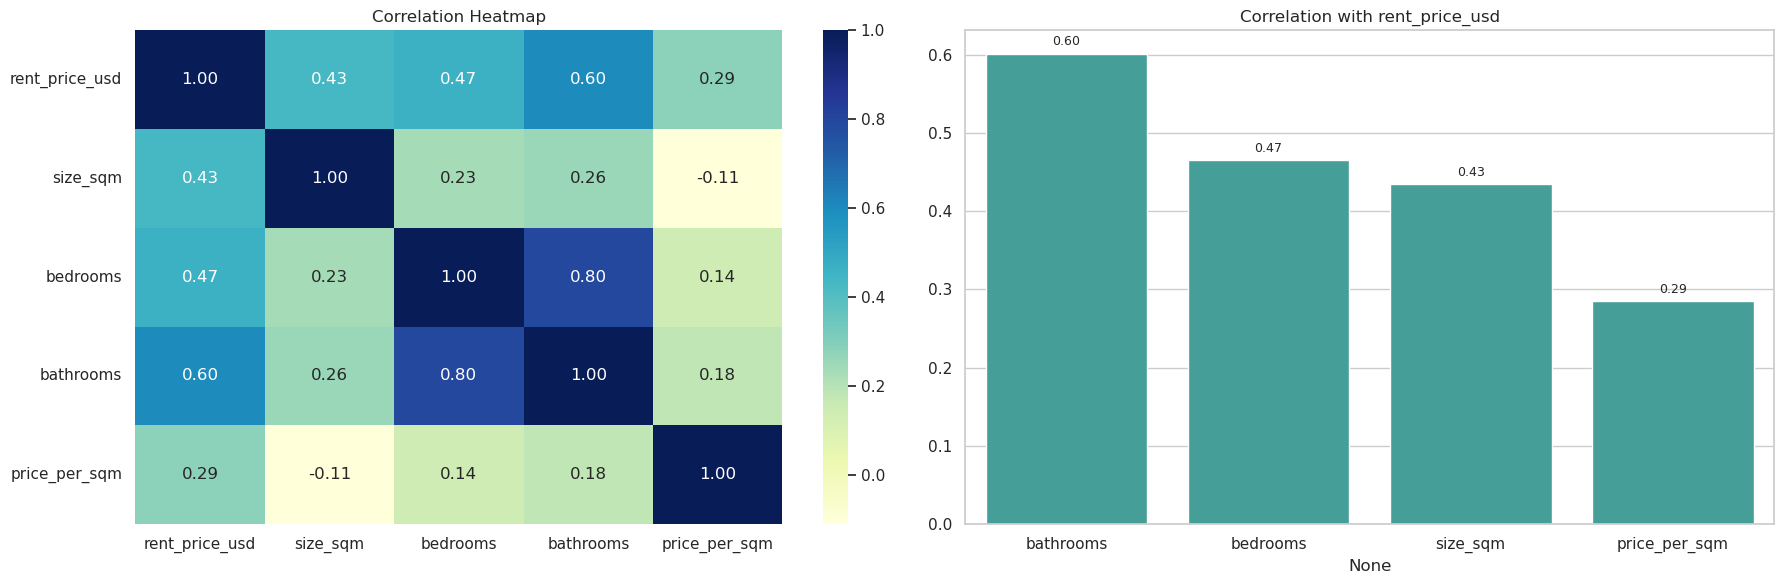

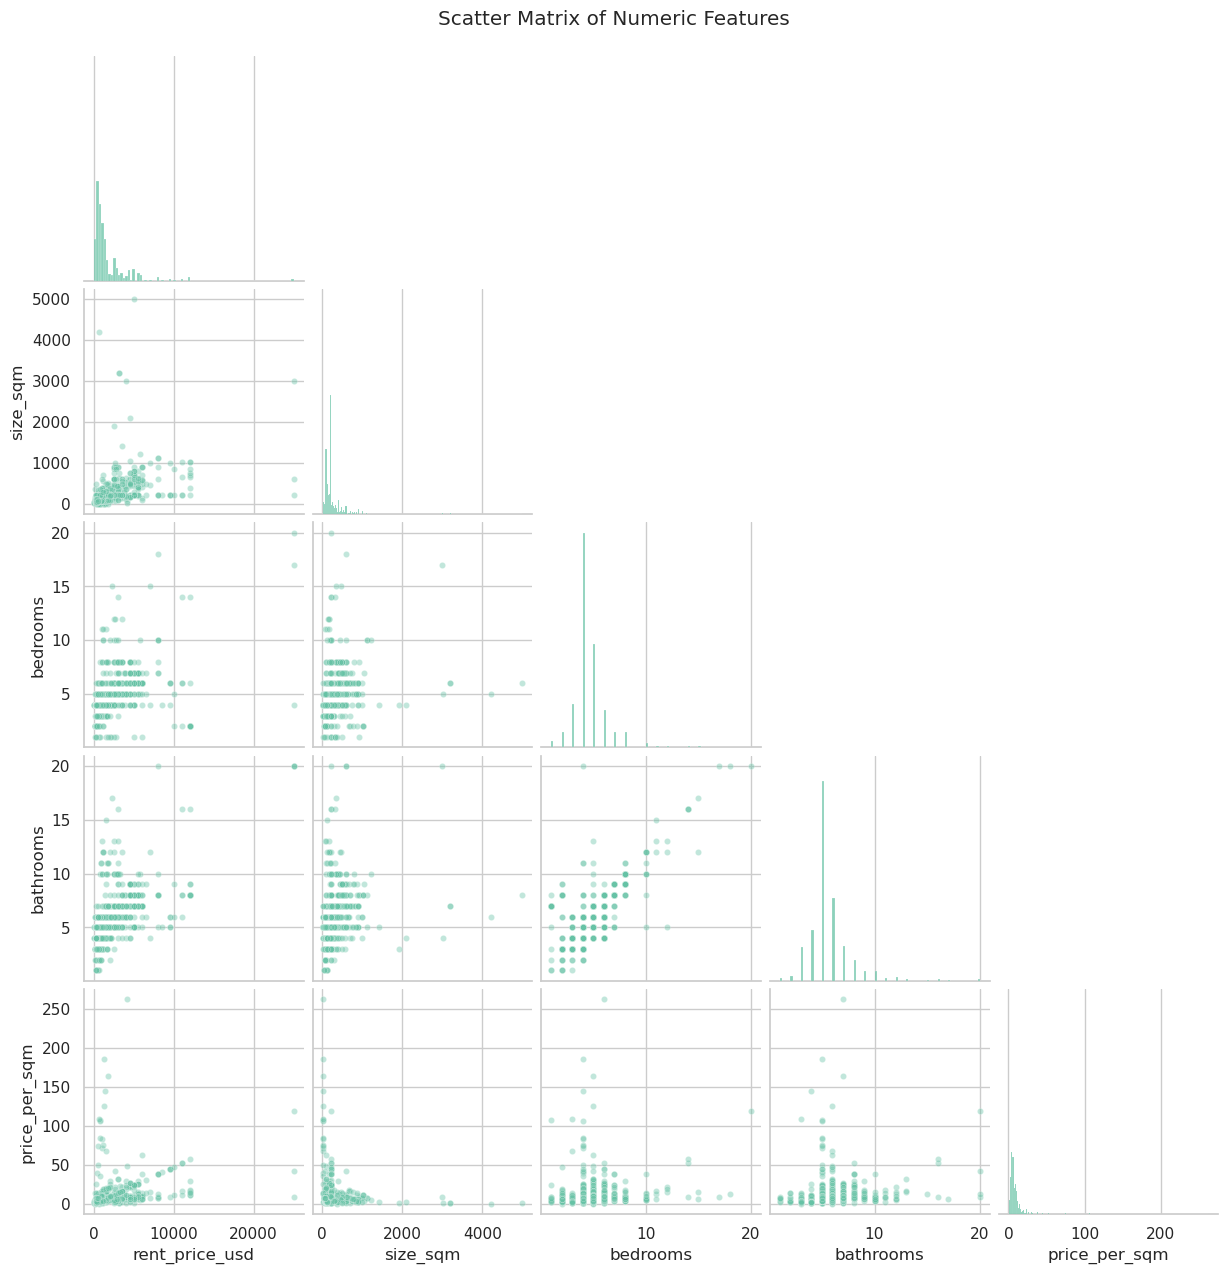

Phase 3 stats
                rent_price_usd  size_sqm  bedrooms  bathrooms  price_per_sqm
rent_price_usd           1.000     0.435     0.465      0.601          0.285
size_sqm                 0.435     1.000     0.234      0.255         -0.109
bedrooms                 0.465     0.234     1.000      0.796          0.145
bathrooms                0.601     0.255     0.796      1.000          0.182
price_per_sqm            0.285    -0.109     0.145      0.182          1.000

Top 3 correlations with rent
bathrooms    0.601
bedrooms     0.465
size_sqm     0.435

Multicollinearity risk (|r| > 0.8): None

Insight: Bathrooms is the strongest single numeric predictor of rent.
No inter-feature correlation exceeded the 0.8 multicollinearity threshold.
Business interpretation: You can keep all core numeric predictors without severe redundancy risk.


In [9]:
numeric_cols = ["rent_price_usd", "size_sqm", "bedrooms", "bathrooms", "price_per_sqm"]
corr_matrix = df[numeric_cols].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Correlation Heatmap")

corr_with_rent = corr_matrix["rent_price_usd"].drop("rent_price_usd").sort_values(ascending=False)
bars = sns.barplot(x=corr_with_rent.index, y=corr_with_rent.values, ax=axes[1], color=sns.color_palette("husl")[3])
for p in bars.patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9, xytext=(0, 4), textcoords="offset points")
axes[1].set_title("Correlation with rent_price_usd")

fig.tight_layout()
fig.savefig(chart_dir / "phase3_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

pairplot = sns.pairplot(df[numeric_cols], corner=True, diag_kind="hist", plot_kws={"alpha": 0.4, "s": 20})
pairplot.fig.suptitle("Scatter Matrix of Numeric Features", y=1.02)
pairplot.savefig(chart_dir / "phase3_scatter_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("Phase 3 stats")
print(corr_matrix.round(3).to_string())
print("\nTop 3 correlations with rent")
print(corr_with_rent.head(3).round(3).to_string())

abs_corr = corr_matrix.abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
high_pairs = upper.stack()[upper.stack() > 0.8]
if len(high_pairs) == 0:
    print("\nMulticollinearity risk (|r| > 0.8): None")
else:
    print("\nMulticollinearity risk pairs:")
    print(high_pairs.round(3).to_string())

print("\nInsight: Bathrooms is the strongest single numeric predictor of rent.")
print("No inter-feature correlation exceeded the 0.8 multicollinearity threshold.")
print("Business interpretation: You can keep all core numeric predictors without severe redundancy risk.")

## Phase 4 — Multivariate Analysis

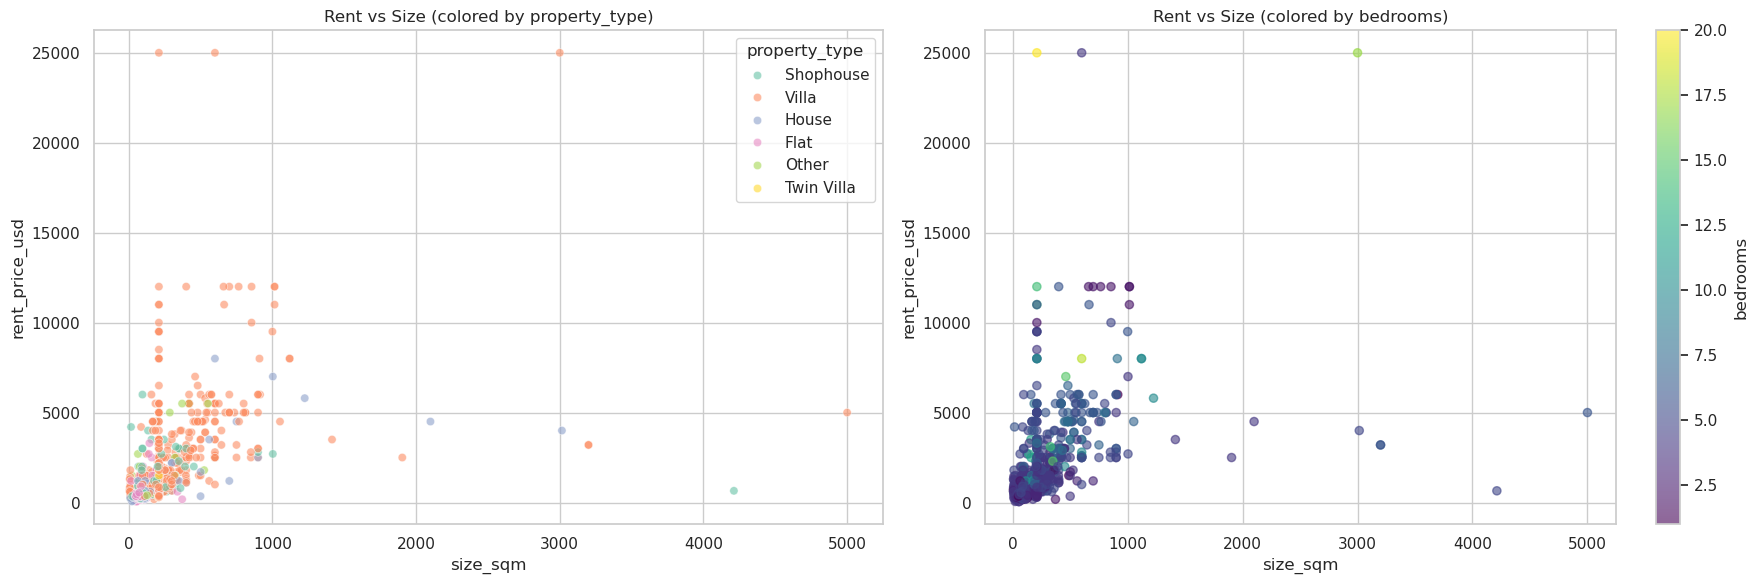

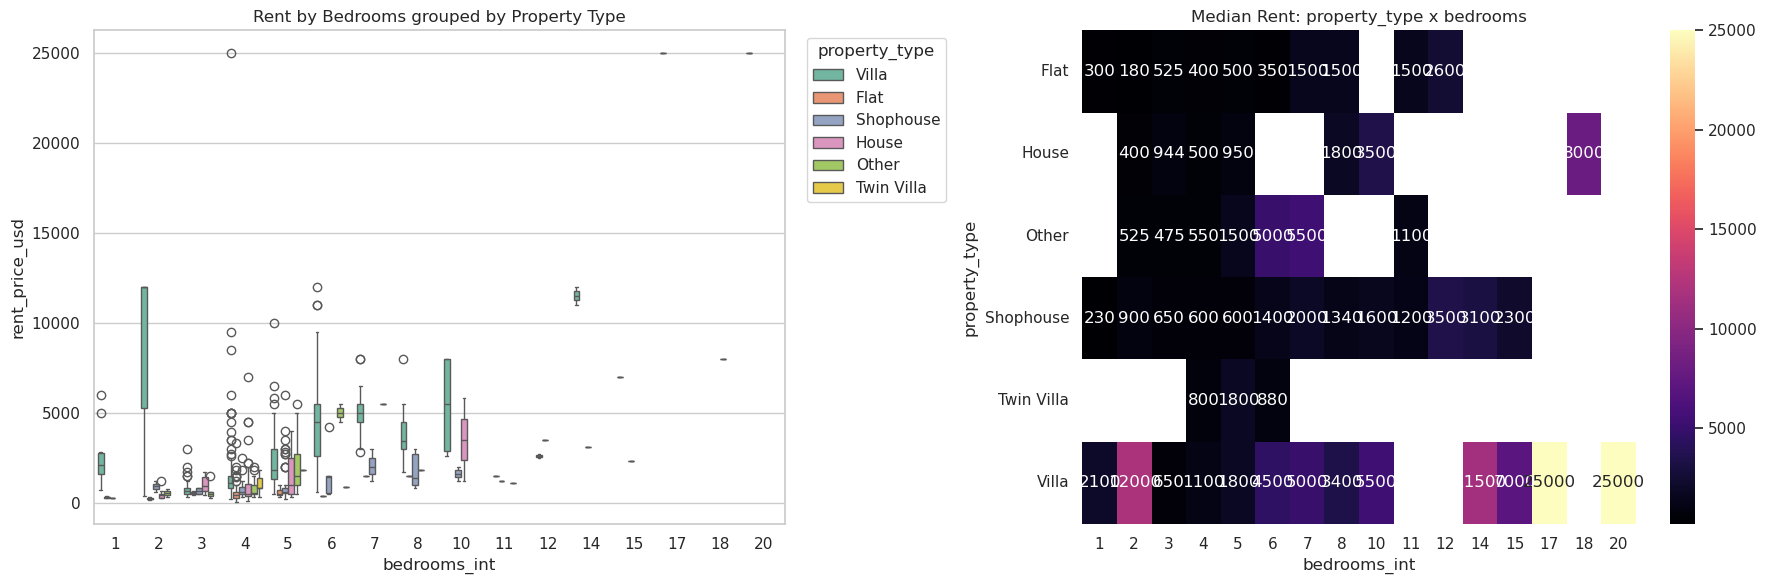

Phase 4 stats
bedrooms_int       1        2      3       4       5       6       7       8       10      11      12       14      15       17      18       20
property_type                                                                                                                                   
Flat            300.0    180.0  525.0   400.0   500.0   350.0  1500.0  1500.0     NaN  1500.0  2600.0      NaN     NaN      NaN     NaN      NaN
House             NaN    400.0  944.0   500.0   950.0     NaN     NaN  1800.0  3500.0     NaN     NaN      NaN     NaN      NaN  8000.0      NaN
Other             NaN    525.0  475.0   550.0  1500.0  5000.0  5500.0     NaN     NaN  1100.0     NaN      NaN     NaN      NaN     NaN      NaN
Shophouse       230.0    900.0  650.0   600.0   600.0  1400.0  2000.0  1340.0  1599.5  1200.0  3500.0   3100.0  2300.0      NaN     NaN      NaN
Twin Villa        NaN      NaN    NaN   800.0  1800.0   880.0     NaN     NaN     NaN     NaN     NaN      NaN     N

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=df, x="size_sqm", y="rent_price_usd", hue="property_type", alpha=0.6, ax=axes[0])
axes[0].set_title("Rent vs Size (colored by property_type)")

scatter = axes[1].scatter(df["size_sqm"], df["rent_price_usd"], c=df["bedrooms"], cmap="viridis", alpha=0.6, s=35)
axes[1].set_title("Rent vs Size (colored by bedrooms)")
axes[1].set_xlabel("size_sqm")
axes[1].set_ylabel("rent_price_usd")
plt.colorbar(scatter, ax=axes[1], label="bedrooms")

fig.tight_layout()
fig.savefig(chart_dir / "phase4_multivariate_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

bedroom_int = df["bedrooms"].round().astype(int)
pivot = (
    df.assign(bedrooms_int=bedroom_int)
    .pivot_table(index="property_type", columns="bedrooms_int", values="rent_price_usd", aggfunc="median")
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=df.assign(bedrooms_int=bedroom_int), x="bedrooms_int", y="rent_price_usd", hue="property_type", ax=axes[0])
axes[0].set_title("Rent by Bedrooms grouped by Property Type")
axes[0].legend(title="property_type", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="magma", ax=axes[1])
axes[1].set_title("Median Rent: property_type x bedrooms")

fig.tight_layout()
fig.savefig(chart_dir / "phase4_heatmap_type_bedrooms.png", dpi=200, bbox_inches="tight")
plt.show()

print("Phase 4 stats")
print(pivot.round(2).to_string())

print("\nInsight: Villas show the widest rent variation across bedroom counts.")
print("Size alone does not explain rent; property type moderates the size-price relationship.")
print("Business interpretation: Use type-specific pricing bands for better valuation accuracy.")

## Phase 5 — Outlier Detection

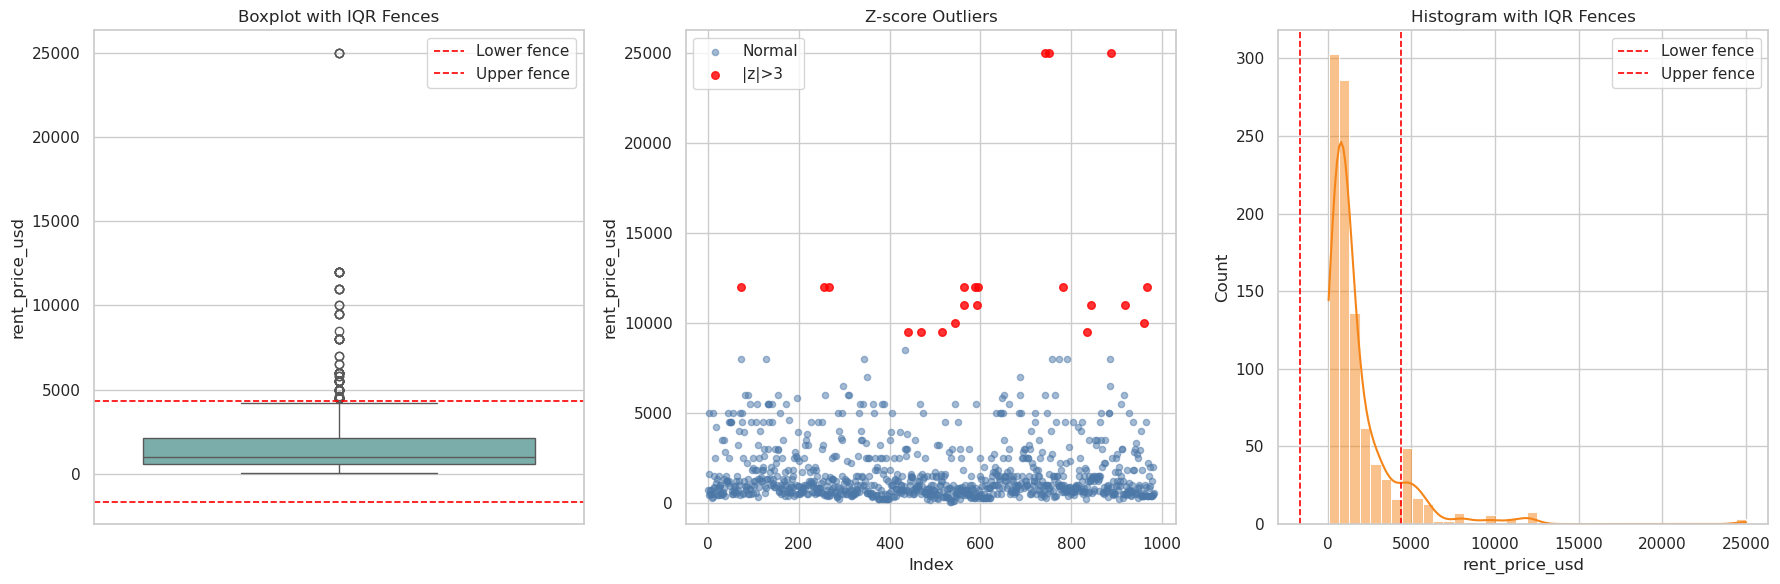

Phase 5 stats
Q1=600.00, Q3=2100.00, IQR=1500.00
Lower fence=-1650.00, Upper fence=4350.00
IQR outliers: 112 (11.39%)
Z-score outliers: 21 (2.14%)

Top 10 expensive
listing_id property_type  size_sqm  bedrooms  bathrooms  rent_price_usd
ID13135210         Villa     600.0       4.0       20.0           25000
ID13158659         Villa    3000.0      17.0       20.0           25000
ID12947695         Villa     210.0      20.0       20.0           25000
ID12642079         Villa    1015.0       2.0        8.0           12000
ID13086632         Villa     700.0       2.0        8.0           12000
ID13086651         Villa    1015.0       2.0        8.0           12000
ID12675179         Villa     210.0      14.0       16.0           12000
ID12978274         Villa     660.0       2.0        9.0           12000
ID13016086         Villa     765.0       2.0        9.0           12000
ID13231136         Villa     400.0       6.0        8.0           12000

Top 10 cheapest
listing_id property_type  

In [11]:
rent = df["rent_price_usd"]
q1 = rent.quantile(0.25)
q3 = rent.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

zscores = np.abs(stats.zscore(rent, nan_policy="omit"))
iqr_mask = (rent < lower_fence) | (rent > upper_fence)
z_mask = zscores > 3

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=rent, ax=axes[0], color="#72B7B2")
axes[0].axhline(lower_fence, color="red", linestyle="--", linewidth=1.2, label="Lower fence")
axes[0].axhline(upper_fence, color="red", linestyle="--", linewidth=1.2, label="Upper fence")
axes[0].set_title("Boxplot with IQR Fences")
axes[0].legend()

idx = np.arange(len(df))
axes[1].scatter(idx[~z_mask], rent[~z_mask], s=20, alpha=0.5, label="Normal", color="#4C78A8")
axes[1].scatter(idx[z_mask], rent[z_mask], s=30, alpha=0.8, label="|z|>3", color="red")
axes[1].set_title("Z-score Outliers")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("rent_price_usd")
axes[1].legend()

sns.histplot(rent, bins=40, kde=True, ax=axes[2], color="#F58518")
axes[2].axvline(lower_fence, color="red", linestyle="--", linewidth=1.2, label="Lower fence")
axes[2].axvline(upper_fence, color="red", linestyle="--", linewidth=1.2, label="Upper fence")
axes[2].set_title("Histogram with IQR Fences")
axes[2].legend()

fig.tight_layout()
fig.savefig(chart_dir / "phase5_outlier_detection.png", dpi=200, bbox_inches="tight")
plt.show()

iqr_count = int(iqr_mask.sum())
z_count = int(z_mask.sum())
iqr_pct = iqr_count / len(df) * 100
z_pct = z_count / len(df) * 100

print("Phase 5 stats")
print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Lower fence={lower_fence:.2f}, Upper fence={upper_fence:.2f}")
print(f"IQR outliers: {iqr_count} ({iqr_pct:.2f}%)")
print(f"Z-score outliers: {z_count} ({z_pct:.2f}%)")

print("\nTop 10 expensive")
print(df.nlargest(10, "rent_price_usd")[["listing_id", "property_type", "size_sqm", "bedrooms", "bathrooms", "rent_price_usd"]].to_string(index=False))
print("\nTop 10 cheapest")
print(df.nsmallest(10, "rent_price_usd")[["listing_id", "property_type", "size_sqm", "bedrooms", "bathrooms", "rent_price_usd"]].to_string(index=False))

print("\nInsight: IQR captures a wider premium tail while Z-score flags only extreme spikes.")
print("Most upper outliers are likely luxury inventory, so they should generally be kept with log-target modeling.")
print("Business interpretation: Retain outliers for realistic market range and reduce influence via log-transformed target.")

## Final Summary Report

In [12]:
corr_rank = corr_with_rent.sort_values(ascending=False)
villa_share = (df["property_type"].eq("Villa").mean() * 100)
twin_share = (df["property_type"].eq("Twin Villa").mean() * 100)
villa_median = df.loc[df["property_type"] == "Villa", "rent_price_usd"].median()

print("1. TOP FEATURES FOR MODELING")
for feature, value in corr_rank.items():
    print(f"   - {feature:<12}: r={value:.3f}")

print("\n2. KEY PATTERNS")
print(f"   - Rent skew={df['rent_price_usd'].skew():.2f}; log transform required")
print(f"   - Villa share={villa_share:.1f}% and median Villa rent=${villa_median:.0f}")
print(f"   - Median rent=${df['rent_price_usd'].median():.0f}, Mean=${df['rent_price_usd'].mean():.0f}")
print(f"   - IQR outliers={iqr_count} ({iqr_pct:.1f}%), upper fence=${upper_fence:.0f}")
print("   - No |r| > 0.8 multicollinearity among numeric features")

print("\n3. DATA QUALITY NOTES")
print(f"   - >=15 bedrooms and >=$20,000 listings: {len(df[(df['bedrooms'] >= 15) & (df['rent_price_usd'] >= 20000)])}")
print(f"   - Flat listings <=$100: {len(df[(df['property_type'] == 'Flat') & (df['rent_price_usd'] <= 100)])}")
print(f"   - Imbalance remains (Villa={villa_share:.1f}%, Twin Villa={twin_share:.1f}%)")

print("\n4. FEATURE ENGINEERING BEFORE MODELING")
print("   - log_rent = log1p(rent_price_usd)")
print("   - price_per_sqm = rent_price_usd / size_sqm")
print("   - room_ratio = bathrooms / bedrooms")
print("   - total_rooms = bedrooms + bathrooms")
print("   - one-hot encode property_type")
print("   - drop listing_id and city")

print("\n5. MODEL RECOMMENDATIONS")
print("   - Use log1p(rent_price_usd) as target and back-transform for final error reporting")
print("   - Baseline: linear regression")
print("   - Primary: Random Forest / LightGBM / XGBoost")
print("   - Consider separate model for Villa due to dominance and variance")

1. TOP FEATURES FOR MODELING
   - bathrooms   : r=0.601
   - bedrooms    : r=0.465
   - size_sqm    : r=0.435
   - price_per_sqm: r=0.285

2. KEY PATTERNS
   - Rent skew=4.38; log transform required
   - Villa share=60.8% and median Villa rent=$1300
   - Median rent=$1000, Mean=$1831
   - IQR outliers=112 (11.4%), upper fence=$4350
   - No |r| > 0.8 multicollinearity among numeric features

3. DATA QUALITY NOTES
   - >=15 bedrooms and >=$20,000 listings: 2
   - Flat listings <=$100: 2
   - Imbalance remains (Villa=60.8%, Twin Villa=1.3%)

4. FEATURE ENGINEERING BEFORE MODELING
   - log_rent = log1p(rent_price_usd)
   - price_per_sqm = rent_price_usd / size_sqm
   - room_ratio = bathrooms / bedrooms
   - total_rooms = bedrooms + bathrooms
   - one-hot encode property_type
   - drop listing_id and city

5. MODEL RECOMMENDATIONS
   - Use log1p(rent_price_usd) as target and back-transform for final error reporting
   - Baseline: linear regression
   - Primary: Random Forest / LightGBM / XG